# EDA

In [5]:
# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# First set seaborn style
sns.set_style("whitegrid")
sns.set_context("notebook")

# Configure plot parameters
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = ['Arial', 'sans-serif']

# Additional configurations for Arabic text
plt.rcParams['axes.unicode_minus'] = False
mpl.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']

# Set larger font sizes
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Set figure DPI
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

# Enable RTL support
plt.rcParams['axes.formatter.use_locale'] = True

# Verify the style was applied
print("Plot style configured successfully")

Plot style configured successfully


In [11]:
# Load the dataset
import pandas as pd
from sklearn.model_selection import train_test_split


file_path = '/Users/alielsamra/Desktop/arabic-dialect-sentiment-analysis/data/raw/ar_reviews_100k.tsv'
try:
    df = pd.read_csv(file_path, sep='\t')
    
    # Split into train, validation, and test sets
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
    
    print("Dataset sizes:")
    print(f"Train: {len(train_df)} samples")
    print(f"Validation: {len(val_df)} samples")
    print(f"Test: {len(test_df)} samples")
    
    print("\nFirst few rows of training data:")
    print(train_df.head())
    
except Exception as e:
    print(f"Error loading dataset: {str(e)}")

Dataset sizes:
Train: 79999 samples
Validation: 10000 samples
Test: 10000 samples

First few rows of training data:
          label                                               text
64470     Mixed  رواية بسيطه عن مغترب تونسي يزور عائلته في اجاز...
45557     Mixed                   حسن. . لا يوجد بركة سباحه للطفال
27614  Positive  جدا مريح نفسيا ونظيف . الطاقم جدا ممتاز شخص سع...
13568  Positive  ممتاز. الشقق ممتازة وطاقم العاملين رائعين وبشو...
92726  Negative  ضعيف جدا. الموقع. طلبت غرفه اضافيه وتفاجئت بان...


## 1. Label Distribution Analysis


Label distribution across splits:


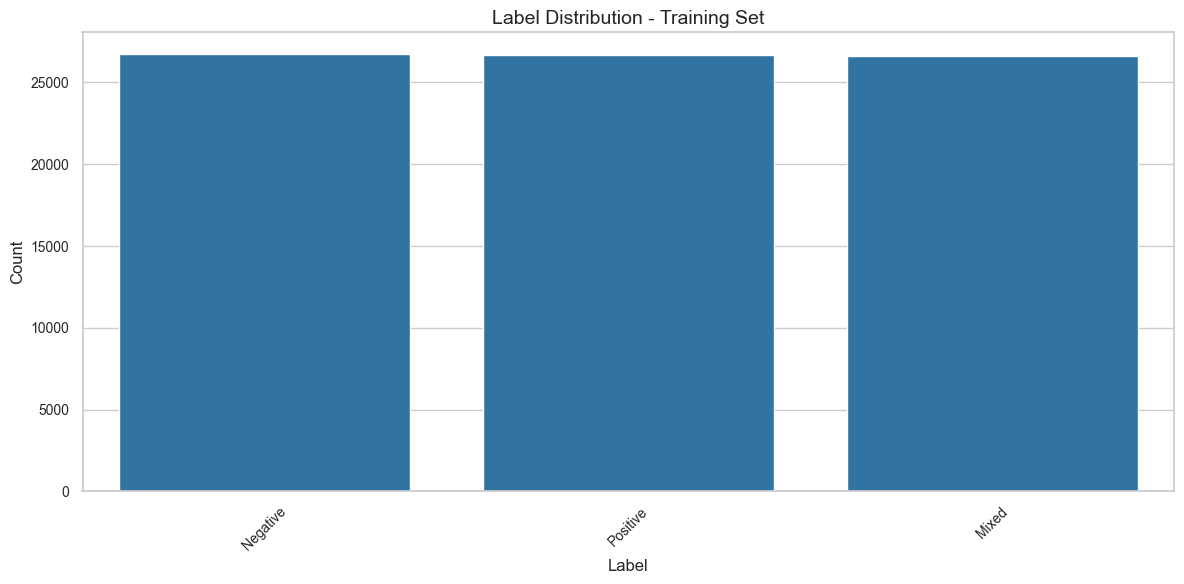


Label percentages in Training Set:
Negative: 33.41%
Positive: 33.32%
Mixed: 33.26%


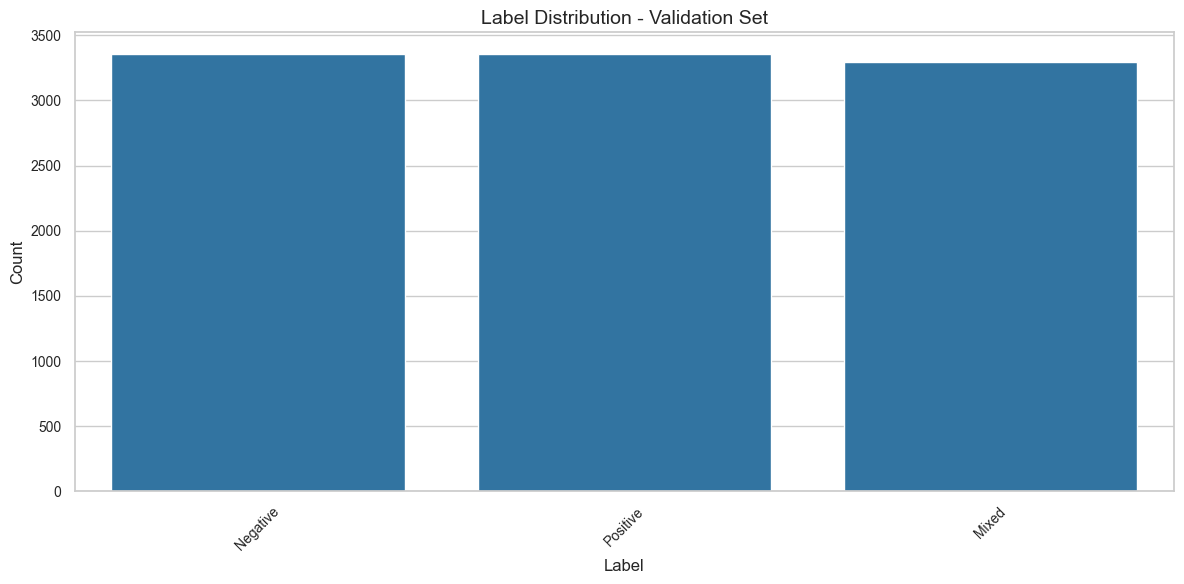


Label percentages in Validation Set:
Negative: 33.54%
Positive: 33.54%
Mixed: 32.92%


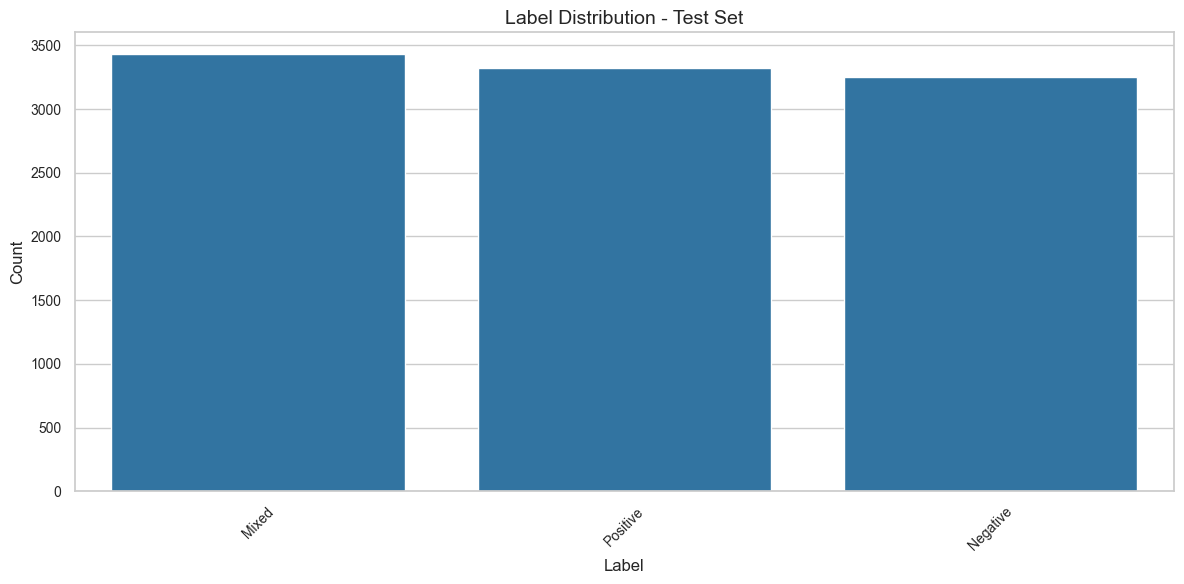


Label percentages in Test Set:
Mixed: 34.3%
Positive: 33.21%
Negative: 32.49%


In [12]:
def plot_label_distribution(df, title):
    plt.figure(figsize=(12, 6))
    label_counts = df['label'].value_counts()
    sns.barplot(x=label_counts.index, y=label_counts.values)
    plt.title(f'Label Distribution - {title}')
    plt.xticks(rotation=45)
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    
    # Print percentages
    percentages = (label_counts / len(df) * 100).round(2)
    print(f"\nLabel percentages in {title}:")
    for label, pct in percentages.items():
        print(f"{label}: {pct}%")

print("Label distribution across splits:")
plot_label_distribution(train_df, 'Training Set')
plot_label_distribution(val_df, 'Validation Set')
plot_label_distribution(test_df, 'Test Set')

## 2. Text Length Analysis


In [ ]:
def add_text_length_features(df, text_column='text'):
    df['char_length'] = df[text_column].str.len()
    df['word_count'] = df[text_column].str.split().str.len()
    return df

# Add length features to all splits
train_df = add_text_length_features(train_df, text_column='text')
val_df = add_text_length_features(val_df, text_column='text')
test_df = add_text_length_features(test_df, text_column='text')

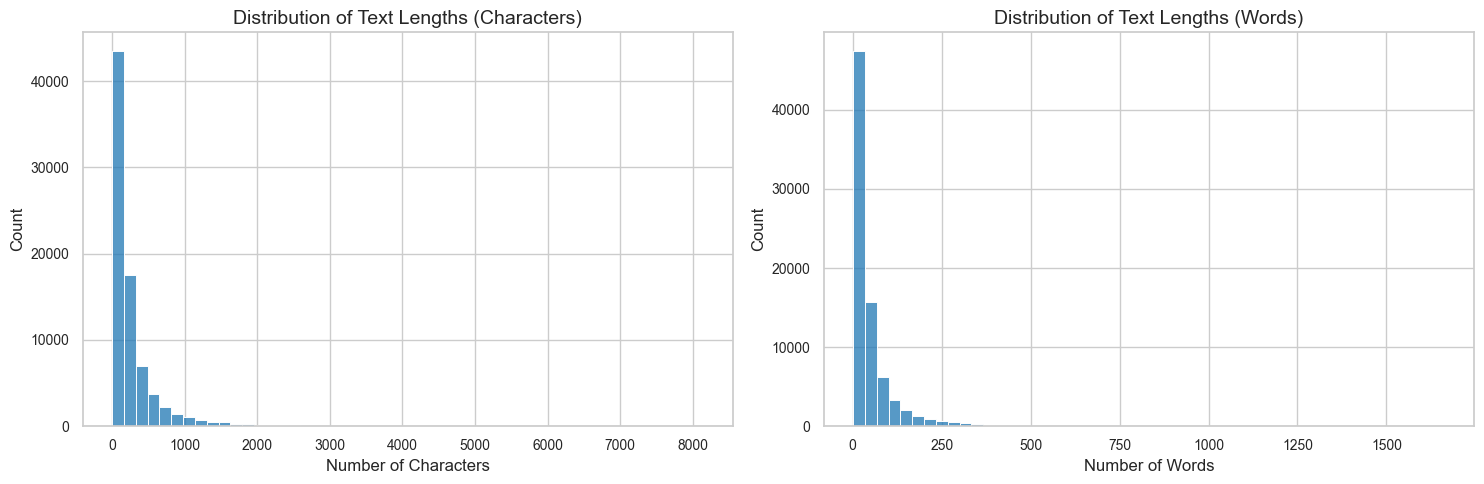

In [15]:
# Plot text length distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=train_df, x='char_length', bins=50, ax=ax1)
ax1.set_title('Distribution of Text Lengths (Characters)')
ax1.set_xlabel('Number of Characters')

sns.histplot(data=train_df, x='word_count', bins=50, ax=ax2)
ax2.set_title('Distribution of Text Lengths (Words)')
ax2.set_xlabel('Number of Words')

plt.tight_layout()
plt.show()

In [16]:
# Print text length statistics
print("\nText length statistics (Training Set):")
stats_df = train_df[['char_length', 'word_count']].describe()
print(stats_df.round(2))


Text length statistics (Training Set):
       char_length  word_count
count     79999.00    79999.00
mean        298.98       55.29
std         520.75       96.69
min           1.00        1.00
25%          69.00       13.00
50%         144.00       26.00
75%         311.00       57.00
max        8145.00     1663.00


In [19]:
# Print examples of shortest and longest texts
print("\nShortest text example:")
shortest = train_df.loc[train_df['word_count'].idxmin()]
print(f"Text: {shortest['text']}")
print(f"Words: {shortest['word_count']}")

print("\nLongest text example:")
longest = train_df.loc[train_df['word_count'].idxmax()]
print(f"Text: {longest['text']}")
print(f"Words: {longest['word_count']}")


Shortest text example:
Text: ائعة:
Words: 1

Longest text example:
Text: اعجبني الكتاب بالمجمل خصوصا فقره الحب ما هو و فقره دعاء العبد الخطاء و اقتبس من هذا الكتاب ما يلي. الحب ما هو لو سألني أحدكم .. ما هي علامات الحب وما شواهده لقلت بلا تردد أن يكون القرب من المحبوبة أشبه بالجلوس في التكييف في يوم شديد الحرارة وأشبه باستشعار الدفء في يوم بارد .. لقلت هي الألفة ورفع الكلفة وأن تجد نفسك في غير حاجة إلى الكذب .. وأن يرفع الحرج بينكما ، فترى نفسك تتصرف على طبيعتك دون أن تحاول أن تكون شيئا آخر لتعجبها .. وأن تصمتا أنتما الاثنان فيحلو الصمت وأن يتكلم أحدكما فيحلو الإصغاء .. وأن تكون الحياة معا هي مطلب كل منكما قبل النوم معا .. وألا يطفىء الفراش هذه الأشواق ولا يورث الملل ولا الضجر وإنما يورث الراحة والمودة والصداقة .. وأن تخلو العلاقة من التشنج والعصبية والعناد والكبرياء الفارغة والغيرة السخيفة والشك الأحمق والرغبة في التسلط ، فكل هذه الأشياء من علامات الأنانية وحب النفس وليست من علامات الحب الآخر .. وأن تكون السكينة والأمان و الطمأنينة هي الحالة النفسية كلما التقيتما . وآلا يطول بينكما ا

## 3. Common Words Analysis


In [21]:
from collections import Counter
import arabic_reshaper
from bidi.algorithm import get_display

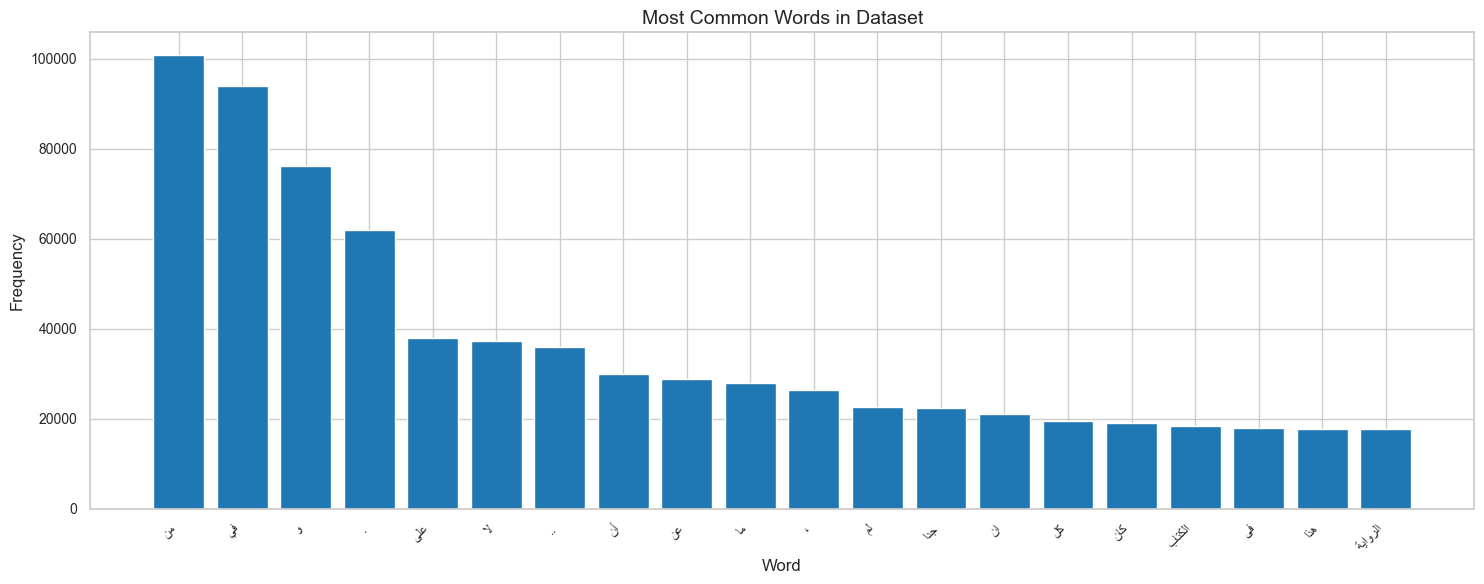


Top 20 most common words:
من: 100867
في: 93925
و: 76131
.: 62068
على: 37957
لا: 37292
..: 36018
أن: 30020
عن: 28851
ما: 28017
،: 26416
لم: 22699
جدا: 22414
ان: 21056
كل: 19518
كان: 19005
الكتاب: 18439
فى: 18027
هذا: 17785
الرواية: 17741


In [22]:
def get_top_words(texts, n=20):
    # Combine all texts and split into words
    words = [word for text in texts for word in text.split()]
    return Counter(words).most_common(n)

# Get top words overall
top_words = get_top_words(train_df['text'])
# Plot top words
plt.figure(figsize=(15, 6))
words, counts = zip(*top_words)

# Handle Arabic text display
words = [get_display(arabic_reshaper.reshape(w)) for w in words]

plt.bar(range(len(counts)), counts)
plt.xticks(range(len(counts)), words, rotation=45, ha='right')
plt.title('Most Common Words in Dataset')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Print top words with their counts
print("\nTop 20 most common words:")
for word, count in top_words:
    print(f"{word}: {count}")

### **Top 20 Most Common Arabic Words (with English Translations)**
Arabic lesson for free :)

| Arabic Word | English Translation        | Notes                                      |
|-------------|----------------------------|--------------------------------------------|
| من          | from                        | Preposition                                 |
| في          | in                          | Preposition                                 |
| و           | and                         | Conjunction                                 |
| .           | . (punctuation)             | Full stop                                   |
| على         | on / upon                   | Preposition                                 |
| لا          | no / not                    | Negation                                    |
| ..          | .. (punctuation)            | Ellipsis / pause                            |
| أن          | that / to                   | Subordinating particle                      |
| عن          | about / regarding           | Preposition                                 |
| ما          | what / not                  | Question or negation depending on context   |
| ،           | , (Arabic comma)            | Punctuation                                 |
| لم          | did not                     | Past tense negation                         |
| جدا         | very                        | Adverb of intensity                         |
| ان          | that                        | Particle similar to "أن" (spelling variant) |
| كل          | every / all                 | Universal quantifier                        |
| كان         | was                         | Past tense of "to be"                       |
| الكتاب      | the book                    | Noun (frequent in book/product reviews)     |
| فى          | in                          | Alternate spelling of "في"                  |
| هذا         | this                        | Demonstrative pronoun                       |
| الرواية     | the novel                   | Common noun in review content               |

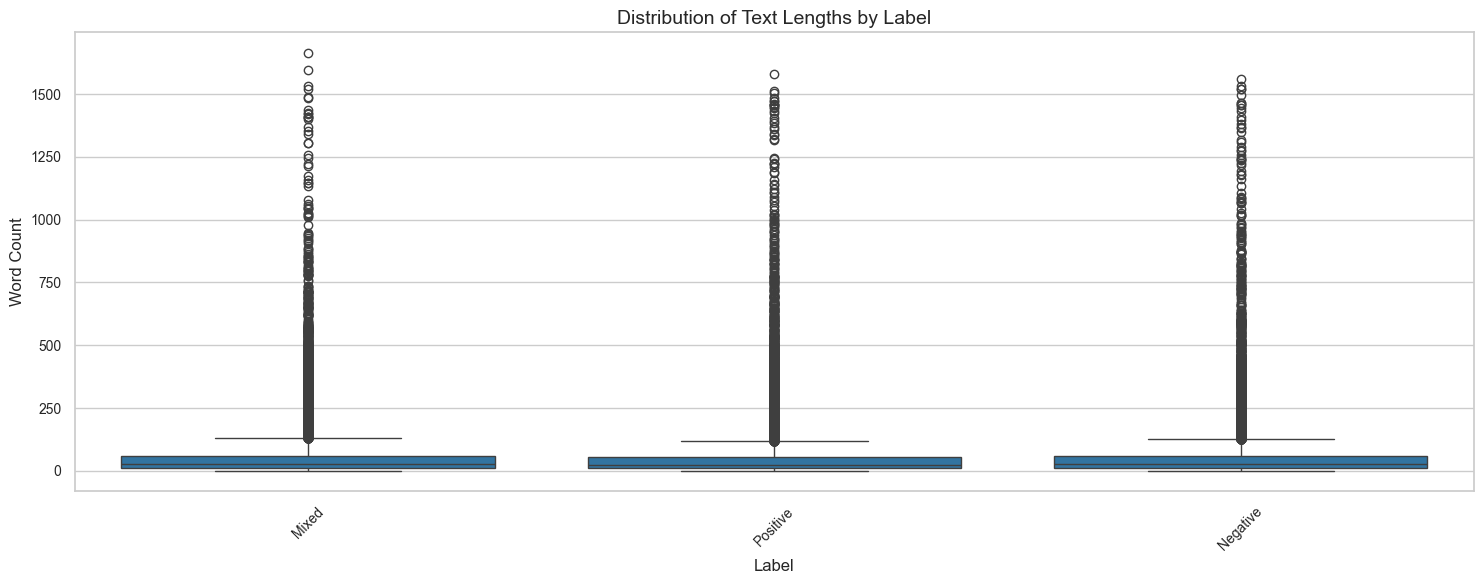


Text length statistics by label:
         word_count                         
               mean     std min   max  count
label                                       
Mixed         56.02   93.84   1  1663  26611
Negative      55.30   95.44   1  1561  26730
Positive      54.55  100.67   1  1580  26658


In [30]:
# 4. Text Length by Label
plt.figure(figsize=(15, 6))
sns.boxplot(data=train_df, x='label', y='word_count')
plt.xticks(rotation=45)
plt.title('Distribution of Text Lengths by Label')
plt.xlabel('Label')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()

# Calculate and display statistics by label
label_stats = train_df.groupby('label').agg({
    'word_count': ['mean', 'std', 'min', 'max', 'count']
}).round(2)

print("\nText length statistics by label:")
print(label_stats)

## 5. Sample Texts Analysis


In [25]:
print("Random samples from each label:")
for label in train_df['label'].unique():
    samples = train_df[train_df['label'] == label].sample(n=2, random_state=42)
    print(f"\nLabel: {label}")
    for _, sample in samples.iterrows():
        print(f"Text: {sample['text']}")
        print(f"Word count: {sample['word_count']}")
        print("---")

Random samples from each label:

Label: Mixed
Text: كويس بس لو كان تصور الشخصيات اللى هتروح الجنه والنار انهم شخصيات وهميه مش موجوده .. كان هيبقى وضح النقطه اللى بيحذر الناس منها فى نفس الوقت مش هيفترض مين اللى هيدخل الجنه ومين اللى هيدخل الانار بالاسماء . غير كده القصص فيها حكم معينه عايز يوصلها. .. ممكن تزيد اقتناع شخص مقتنع من البداية :
Word count: 56
---
Text: مرضي. السعر رخيص مفارنه ب الفنادق نجوم. التكيف جدا سئ ما انصح احد يسكن فيه بالصيف
Word count: 16
---

Label: Positive
Text: اختياري لفندق رافلز . جميع الخدمات المقدمه رائعه جدا الغرفه مريحه الافطار فاخر متنوع ونظيف الموقع ممتاز. السجاد في الغرفه قديم تراجع مستوى نظافة دورات المياه في الغرفه كانت افضل في زيارتي السابقه
Word count: 33
---
Text: هذا الكتاب أسطوري و رائع لدرجة الروعة : . ::::. فيشرع في بداية الكتاب في تحسس بداية الصحوة و نموها و محلها الان من الأعراب و يذكر اهم صفاتها الحالية ثم يرد على منتقيديها و يبدأ هو بالنقد لأخطاء الحركات الصحوية ثم يعرج على آلية التعامل مع الطوائف الصحوية الاخرى اي مع بعضها و آلية التجديد 

### **Random Sample Translations Grouped by Sentiment**

####Mixed Sentiment

**Sample 1:**
- **Arabic:** كويس بس لو كان تصور الشخصيات اللى هتروح الجنه والنار انهم شخصيات وهميه مش موجوده .. كان هيبقى وضح النقطه اللى بيحذر الناس منها فى نفس الوقت مش هيفترض مين اللى هيدخل الجنه ومين اللى هيدخل الانار بالاسماء . غير كده القصص فيها حكم معينه عايز يوصلها. .. ممكن تزيد اقتناع شخص مقتنع من البداية :
- **English:** It's good, but if the portrayal of the characters going to heaven and hell was imaginary and not real people, it would have clarified the point he's warning people about without assuming who will enter heaven or hell by name. Other than that, the stories contain specific morals he's trying to convey. Might increase the conviction of someone already convinced.
- **Word Count:** 56

**Sample 2:**
- **Arabic:** مرضي. السعر رخيص مفارنه ب الفنادق نجوم. التكيف جدا سئ ما انصح احد يسكن فيه بالصيف
- **English:** Acceptable. The price is cheap compared to star-rated hotels. The air conditioning is very bad; I wouldn't recommend anyone stay there in the summer.
- **Word Count:** 16

---

#### Positive Sentiment

**Sample 1:**
- **Arabic:** اختياري لفندق رافلز . جميع الخدمات المقدمه رائعه جدا الغرفه مريحه الافطار فاخر متنوع ونظيف الموقع ممتاز. السجاد في الغرفه قديم تراجع مستوى نظافة دورات المياه في الغرفه كانت افضل في زيارتي السابقه
- **English:** My choice of Raffles Hotel. All the services provided were excellent, the room was comfortable, the breakfast luxurious, varied and clean, and the location was excellent. The carpet in the room was old and the cleanliness of the bathrooms had declined compared to my previous visit.
- **Word Count:** 33

**Sample 2:**
- **Arabic:** هذا الكتاب أسطوري و رائع لدرجة الروعة ... فهرس الأفكار صفحة . انتقادي الوحيد لماذا يرفض الدكتور عبد الكريم سياسة المقاومة و يستشهد بفشل التجربة الجهادية بأفغانستان ... مع ذلك عبد الكريم بكار كاتبي المفضل
- **English:** This book is legendary and absolutely brilliant... The only criticism I have is why Dr. Abdul Karim rejects the idea of resistance and cites the failure of the jihadist experiment in Afghanistan... Nevertheless, Abdul Karim Bakkar is my favorite author.
- **Word Count:** 135

---

#### Negative Sentiment

**Sample 1:**
- **Arabic:** فكرة جميلة هي النظرة المختلفة لالوان الطيف السبعة غيرالتي الفناها ... لا بأس بالكتاب عموما
- **English:** A nice idea is the different perspective on the seven colors of the rainbow, different from what we are used to ... The stories have unique ideas. The book overall is okay.
- **Word Count:** 49

**Sample 2:**
- **Arabic:** جميل جدا مقارنه بسعره المعقول والخدمه المقدمه وبشاشة الموظفين ... لا احد يتحدث اللغه العربيه الا اثنين فقط
- **English:** Very good compared to its reasonable price, the service provided, and the friendliness of the staff... But only two employees speak Arabic.
- **Word Count:** 24

## 6. Data Quality Analysis

In [28]:
print("Missing values in training set:")
print(train_df.isnull().sum())

# Check for empty texts
empty_texts = train_df[train_df['text'].str.strip() == '']
print(f"\nNumber of empty texts: {len(empty_texts)}")

# Check for duplicate texts
duplicates = train_df[train_df.duplicated(subset=['text'], keep=False)]
print(f"Number of duplicate texts: {len(duplicates)}")

if len(duplicates) > 0:
    print("\nSample of duplicate texts:")
    print(duplicates.head())

Missing values in training set:
label          0
text           0
char_length    0
word_count     0
dtype: int64

Number of empty texts: 0
Number of duplicate texts: 0
